# **Assignment 2**
# **Solving 1D Poisson Equation with the Finite-Difference Method**
**Course:** Numerical Analysis For PDE's (WI3730TU)  
**Instructions:** Complete the mathematical derivations and fill in the missing code blocks marked with `# TODO`. Ensure your notebook passes a clean **Kernel -> Restart & Run All** check before submission.

## Boundary Value Problem Statement
Consider the following 1D Poisson boundary-value problem:
$$\quad -\frac{d^{2}u}{dx^{2}} = f(x), \quad x \in (0,3)$$
With the Dirichlet boundary conditions:
$$\quad u(0) = 1, \quad u(3) = 2$$
We test this system using two unique source functions:
1. $f_1(x) = 3x - 2$
2. $f_2(x) = x^2 + 3x - 2$

### **Question 1: Grid Generation & Source Function Visualization (1 p)**
Before analyzing the operator discretization matrix, generate the discrete uniform coordinates and verify your source profiles.

*Complete the code cell below to generate a uniform 1D mesh over the interval $[0,3]$ with $n=5$ sub-intervals. Compute the corresponding grid values for both $f_1(x)$ and $f_2(x)$, and plot them in a single formatted figure featuring a legend and $\LaTeX$ annotations.*

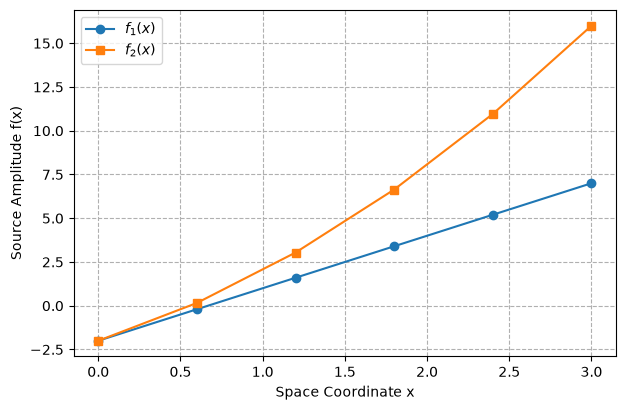

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# TODO: Step 1. Define the analytical source functions as python Callables
def f1(x):
    return 3 * x - 2

def f2(x):
    # YOUR CODE HERE: Implement the second source function
    return x**2 + 3*x - 2
# -------------------------------------------------------------------------

# Step 2. Construct the grid mesh array
n = 5
L = 3.0
x_mesh = np.linspace(0, L, n+1) # REPLACE THIS WITH np.linspace() for the actual grid

# Step 3. Generate your evaluation plot using your functions
plt.figure(figsize=(7, 4.5))
plt.plot(x_mesh, f1(x_mesh), '-o', label=r'$f_1(x)$')
plt.plot(x_mesh, f2(x_mesh), '-s', label=r'$f_2(x)$')
plt.xlabel('Space Coordinate x')
plt.ylabel('Source Amplitude f(x)')
plt.legend()
plt.grid(True, ls='--')
plt.show()

### **Question 2: Finite-Difference Approximation Theory (1 p)**

Write down the $\mathcal{O}(h^2)$ central finite-difference (FD) approximation formula for the negative second derivative operator ($-u''$), including the explicit Lagrange remainder (truncation error) term.

Define what domain range the arbitrary coordinate value $\xi$ belongs to.

---

Consider an interior grid point $x_i$, with $ i=1,\ldots,n-1, \qquad x_i\in(0,3), $ on a uniform grid with spacing $h$. Assume that
$u\in C^4([x_i-h,x_i+h])$, so that the fourth derivative is continuous on the interval required for the Lagrange remainder.

Expanding $u(x_i+h)$ and $u(x_i-h)$ about $x_i$ using Taylor's theorem with the Lagrange form of the remainder gives

$$
\begin{aligned}
u(x_i+h)
&=u(x_i)
+h\,u'(x_i)
+\frac{h^2}{2}u''(x_i)
+\frac{h^3}{6}u'''(x_i)
+\frac{h^4}{24}u^{(4)}(\xi_+),\\[2mm]
u(x_i-h)
&=u(x_i)
-h\,u'(x_i)
+\frac{h^2}{2}u''(x_i)
-\frac{h^3}{6}u'''(x_i)
+\frac{h^4}{24}u^{(4)}(\xi_-),
\end{aligned}
$$

where $ \xi_+\in(x_i,x_i+h) $ and $ \xi_-\in(x_i-h,x_i). $ Adding the two Taylor expansions cancels the first- and third-derivative terms:

$$
u(x_i+h)-2u(x_i)+u(x_i-h)
=
h^2u''(x_i)
+
\frac{h^4}{24}
\left[
u^{(4)}(\xi_+)+u^{(4)}(\xi_-)
\right].
$$

Dividing by $h^2$ gives

$$
\frac{u_{i-1}-2u_i+u_{i+1}}{h^2}
=
u''(x_i)
+
\frac{h^2}{24}
\left[
u^{(4)}(\xi_+)+u^{(4)}(\xi_-)
\right],
$$

where $u_i=u(x_i)$. Since $u^{(4)}$ is continuous on $[x_i-h,x_i+h]$, there exists a point $ \xi_i\in(x_i-h,x_i+h)=(x_{j-1},x_{j+1}) $ according to the Intermediate-Value-Theorem such that

$$ \displaystyle
u^{(4)}(\xi_i)
=
\frac{
u^{(4)}(\xi_+)+u^{(4)}(\xi_-)
}{2}.
$$

Hence,

$$
u''(x_i)
=
\frac{u_{i-1}-2u_i+u_{i+1}}{h^2}
-
\frac{h^2}{12}u^{(4)}(\xi_i).
$$

Therefore, for the **negative second derivative operator**,

$$
-u''(x_i)
=
\frac{-u_{i-1}+2u_j-u_{i+1}}{h^2}
+
\frac{h^2}{12}u^{(4)}(\xi_i),
\qquad
\xi_i\in(x_{i-1},x_{i+1}).
$$

If the local truncation error is defined as the exact differential operator minus its finite-difference approximation,

$$
\tau_i
=
-u''(x_i)
-
\frac{-u_{i-1}+2u_i-u_{i+1}}{h^2},
$$

then

$$

\tau_i
=
\frac{h^2}{12}u^{(4)}(\xi_i)
=
\mathcal{O}(h^2).
$$

Thus the central finite-difference approximation is second-order accurate at every interior grid point $x_i$.

### **Question 3: Full System of Finite-Difference Equations (1 p)**

Assuming $n=5$, write down the complete system of $n+1=6$ finite-difference equations for the entire grid layout, explicitly including the boundary nodes $x_0$ and $x_5$.

Provide the explicit equations for the source function $f_1(x)$ only.

---

The spatial domain is $[0,3]$. For $n=5$ uniform sub-intervals, the grid spacing is $ h=\dfrac{3-0}{5}=0.6, $ and the $n+1=6$ grid points are

$$
x_i=ih,\qquad i=0,\ldots,5,
$$

that is,

$$
x_0=0,\qquad
x_1=0.6,\qquad
x_2=1.2,\qquad
x_3=1.8,\qquad
x_4=2.4,\qquad
x_5=3.
$$

The prescribed Dirichlet boundary values are $u_0=u(x_0)=1 $ and $ u_5=u(x_5)=2 $. For the differential equation $ -u''(x)=f_1(x),\qquad x\in(0,3), $ the second-order central finite-difference discretization at each interior node
$x_i$, $i=1,\ldots,4$, is

$$
\frac{-u_{i-1}+2u_i-u_{i+1}}{h^2}=f_1(x_i).
$$

The source function is $ f_1(x)=3x-2, $ so its values at the four interior nodes are

$$
\begin{aligned}
f_1(x_1)&=f_1(0.6)=-0.2,\\
f_1(x_2)&=f_1(1.2)=1.6,\\
f_1(x_3)&=f_1(1.8)=3.4,\\
f_1(x_4)&=f_1(2.4)=5.2.
\end{aligned}
$$

Therefore, the complete system consists of the two Dirichlet boundary
equations and the four interior finite-difference equations:

$$
\begin{aligned}
u_0 &= 1,\\[1mm]
\frac{-u_0+2u_1-u_2}{h^2} &= -0.2,\\[1mm]
\frac{-u_1+2u_2-u_3}{h^2} &= 1.6,\\[1mm]
\frac{-u_2+2u_3-u_4}{h^2} &= 3.4,\\[1mm]
\frac{-u_3+2u_4-u_5}{h^2} &= 5.2,\\[1mm]
u_5 &= 2.
\end{aligned}
$$

At this stage the boundary values have not yet been eliminated. All six
nodal values are therefore retained as components of the full nodal vector,

$$
\mathbf{u}
=
\begin{bmatrix}
u_0\\
u_1\\
u_2\\
u_3\\
u_4\\
u_5
\end{bmatrix},
$$

although $u_0$ and $u_5$ are prescribed by the Dirichlet boundary
conditions rather than being independent unknowns.

The complete algebraic system can consequently be written as

$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 0\\
-\dfrac{1}{h^2} & \dfrac{2}{h^2} & -\dfrac{1}{h^2} & 0 & 0 & 0\\
0 & -\dfrac{1}{h^2} & \dfrac{2}{h^2} & -\dfrac{1}{h^2} & 0 & 0\\
0 & 0 & -\dfrac{1}{h^2} & \dfrac{2}{h^2} & -\dfrac{1}{h^2} & 0\\
0 & 0 & 0 & -\dfrac{1}{h^2} & \dfrac{2}{h^2} & -\dfrac{1}{h^2}\\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
u_0\\
u_1\\
u_2\\
u_3\\
u_4\\
u_5
\end{bmatrix}
=
\begin{bmatrix}
1\\
-0.2\\
1.6\\
3.4\\
5.2\\
2
\end{bmatrix}.
$$

With $h=0.6$, this system represents the complete six-node discretization
before the known boundary values $u_0=1$ and $u_5=2$ are eliminated in the
reduced interior system.

### **Question 4: Linear Algebraic System Derivation (1 p)**
Using the full system of equations from Question 3, mathematically eliminate the known Dirichlet values $u_0 = 1$ and $u_5 = 2$. 

Show how this elimination reduces the system to a compact linear algebraic problem $A\mathbf{u} = \mathbf{f}$, where $A \in \mathbb{R}^{4 \times 4}$.

---
From Question 3, the four interior finite-difference equations are

$$
\frac{-u_0+2u_1-u_2}{h^2}=f(x_1),
$$

$$
\frac{-u_1+2u_2-u_3}{h^2}=f(x_2),
$$

$$
\frac{-u_2+2u_3-u_4}{h^2}=f(x_3),
$$

$$
\frac{-u_3+2u_4-u_5}{h^2}=f(x_4).
$$

Using the boundary conditions $u_0=1, u_5=2,$ the equations become

$$
\frac{2u_1-u_2}{h^2}
=
f(x_1)+\frac{1}{h^2},
$$

$$
\frac{-u_1+2u_2-u_3}{h^2}
=
f(x_2),
$$

$$
\frac{-u_2+2u_3-u_4}{h^2}
=
f(x_3),
$$

$$
\frac{-u_3+2u_4}{h^2}
=
f(x_4)+\frac{2}{h^2}.
$$

With

$$
\mathbf{u}
=
\begin{bmatrix}
u_1\\
u_2\\
u_3\\
u_4
\end{bmatrix},
$$

the reduced system can be written as $A\mathbf{u}=\mathbf{f}$, where

$$
A=
\frac{1}{h^2}
\begin{bmatrix}
2&-1&0&0\\
-1&2&-1&0\\
0&-1&2&-1\\
0&0&-1&2
\end{bmatrix}.
$$

For $f_1(x)=3x-2$,

$$
\mathbf{f}_1=
\begin{bmatrix}
-0.2+\frac{1}{0.36}\\
1.6\\
3.4\\
5.2+\frac{2}{0.36}
\end{bmatrix}
=
\begin{bmatrix}
2.5778\\
1.6\\
3.4\\
10.7556
\end{bmatrix}.
$$

For $f_2(x)=x^2+3x-2$,

$$
\mathbf{f}_2=
\begin{bmatrix}
0.16+\frac{1}{0.36}\\
3.04\\
6.64\\
10.96+\frac{2}{0.36}
\end{bmatrix}
=
\begin{bmatrix}
2.9378\\
3.04\\
6.64\\
16.5156
\end{bmatrix}.
$$


### **Question 5(a): Mathematical Structure of the System Matrix (1 p)**

Before implementing the code, state the exact dimension of your internal system matrix $A$ as a function of the number of sub-intervals $n$.

Write out the algebraic definitions for the entries of the main diagonal ($A_{i,i}$) and the sub/super-diagonals ($A_{i,i-1}$, $A_{i,i+1}$).

---

For a uniform grid with $n$ sub-intervals, there are $n+1$ grid nodes, $ x_0,x_1,\ldots,x_n, $ of which the $n-1$ nodes $ x_i,\qquad i=1,\ldots,n-1, $ are interior nodes. After eliminating the prescribed Dirichlet boundary values
$u_0$ and $u_n$, the unknown solution vector therefore contains $n-1$
components. Hence,

$$
A\in\mathbb{R}^{(n-1)\times(n-1)}.
$$

With the uniform grid spacing $ h=\dfrac{L}{n}, $ the finite-difference approximation

$$
\frac{-u_{i-1}+2u_i-u_{i+1}}{h^2}
$$

gives the following entries of the system matrix:

$$
\begin{aligned}
A_{i,i}
&=\frac{2}{h^2},
&& i=1,\ldots,n-1,\\[1mm]
A_{i,i-1}
&=-\frac{1}{h^2},
&& i=2,\ldots,n-1,\\[1mm]
A_{i,i+1}
&=-\frac{1}{h^2},
&& i=1,\ldots,n-2.
\end{aligned}
$$

All remaining entries are zero. Therefore, $A$ is the symmetric tridiagonal matrix

$$
A=
\frac{1}{h^2}
\begin{bmatrix}
2 & -1 & 0 & \cdots & 0\\
-1 & 2 & -1 & \ddots & \vdots\\
0 & -1 & 2 & \ddots & 0\\
\vdots & \ddots & \ddots & \ddots & -1\\
0 & \cdots & 0 & -1 & 2
\end{bmatrix}.
$$

Thus, $A$ is the $(n-1)\times(n-1)$ finite-difference representation of $-\mathrm{d}^2/\mathrm{d}x^2$ on the
interior grid points under Dirichlet boundary conditions.

### **Question 5(b): Dense Matrix Assembly Function (2 p)**

*Complete the function below to assemble a dense system matrix representing the negative second derivative operator under Dirichlet conditions.*


In [8]:
def assemble_system_matrix(n, L=3.0):
    """
    Constructs the dense tridiagonal FDM matrix A.

    Inputs:
        n : Number of sub-intervals
        L : Physical domain length

    Outputs:
        A : Dense NumPy array of size (n-1) x (n-1)
    """
    h = L / n

    # Main diagonal: 2
    main_diag = 2 * np.ones(n - 1)

    # Sub- and super-diagonals: -1
    off_diag = -1 * np.ones(n - 2)

    # Assemble and scale the discrete negative second-derivative matrix
    A = (
        np.diag(main_diag)
        + np.diag(off_diag, 1)
        + np.diag(off_diag, -1)
    ) / h**2

    return A


# Quick local test for n = 5
A_test = assemble_system_matrix(n=5)
print("Assembled Matrix A (n=5):\n", A_test)

Assembled Matrix A (n=5):
 [[ 5.55555556 -2.77777778  0.          0.        ]
 [-2.77777778  5.55555556 -2.77777778  0.        ]
 [ 0.         -2.77777778  5.55555556 -2.77777778]
 [ 0.          0.         -2.77777778  5.55555556]]


### **Question 6(a): Sizing of the Reduced Right-Hand-Side Vectors (1 p)**

For a number of sub-intervals $n$ and a grid size of $n+1$ nodes, what is the exact vector size of your interior right-hand-side arrays $\mathbf{f}_1$ and $\mathbf{f}_2$ after boundary elimination?

State explicitly which nodes (from $x_0$ to $x_n$) are used to evaluate the source function terms inside this reduced system and how the right-hand side vectors are modified after boundary-value elimination.

---

For a uniform grid with $n$ sub-intervals, there are $n+1$ grid nodes, $ x_0,x_1,\ldots,x_n, $ with grid spacing $ h=\dfrac{L}{n}. $ The Dirichlet boundary values $u_0=u(x_0)$ and $u_n=u(x_n)$ are eliminated from the set of unknowns. The reduced system contains the $n-1$ interior unknowns $ u_i, i=1,\ldots,n-1. $ Consequently, each reduced right-hand-side vector has dimension

$$
\mathbf{f}_1,\mathbf{f}_2\in\mathbb{R}^{\,n-1}.
$$

The source functions are evaluated only at the interior grid nodes, $x_i, i=1,\ldots,n-1$. For a general source function $f(x)$, the finite-difference equation at the first interior node is

$$
\frac{-u_0+2u_1-u_2}{h^2}=f(x_1).
$$

Since $u_0$ is known, its contribution is moved to the right-hand side:

$$
\frac{2u_1-u_2}{h^2}
=
f(x_1)+\frac{u_0}{h^2}.
$$

Similarly, at the last interior node,

$$
\frac{-u_{n-2}+2u_{n-1}-u_n}{h^2}=f(x_{n-1}),
$$

so elimination of the known value $u_n$ gives

$$
\frac{-u_{n-2}+2u_{n-1}}{h^2}
=
f(x_{n-1})+\frac{u_n}{h^2}.
$$

Therefore, the reduced right-hand-side vector is

$$
\mathbf{f}
=
\begin{bmatrix}
f(x_1)+\dfrac{u_0}{h^2}\\
f(x_2)\\
\vdots\\
f(x_{n-2})\\
f(x_{n-1})+\dfrac{u_n}{h^2}
\end{bmatrix}
\in\mathbb{R}^{\,n-1}.
$$

Thus, only the first and last entries are modified by the Dirichlet boundary values.

### **Question 6(b): Right-Hand-Side Assembly Function (2 p)**

**Your task:** complete the function below to dynamically construct the modified RHS vectors for both $f_1(x)$ and $f_2(x)$ using the eliminated Dirichlet boundary values.

----

*Complete the function below to construct a single, modified RHS vector by passing your spatial grid array and your target function handle.*

In [11]:
def assemble_rhs_vector(x_mesh, f_func, u_left=1.0, u_right=2.0):
    """=
    Constructs a generic, reduced right-hand side vector.
    Inputs:
        x_mesh   : The FULL 1D grid coordinate array (including boundaries)
        f_func  : A python function handle/callable evaluating f(x)
        u_left : Value for Dirichlet boundary conditions u(0)
        u_right : Value for Dirichlet boundary conditions u(L)
    Outputs:
        f_rhs   : Modified RHS vector applied with BC adjustments, length (len(xgrid) - 2)
    """
    n = len(x_mesh) - 1
    L = x_mesh[-1] - x_mesh[0]
    h = L / n
    
    # -------------------------------------------------------------------------
    # TODO: Step 1. Extract the interior coordinates from your passed grid array
    x_interior = x_mesh[1:-1]  # REPLACE THIS WITH YOUR INTERIOR MESH STRIDE
    
    # Evaluate the source function dynamically via its functional handle
    f_base = f_func(x_interior)
    
    # TODO: Step 2. Apply your mathematically eliminated boundary modifications
    f_rhs = f_base.copy()
    f_rhs[0] += u_left / h**2
    f_rhs[-1] += u_right / h**2
    
    # YOUR BOUNDARY SHIFTING CODE HERE (Modify the first and last entries)
    
    # -------------------------------------------------------------------------
    return f_rhs

# Quick local test for sample grid [0,1,2,3,4] 
rhs1 = assemble_rhs_vector(x_mesh = np.array([0,1,2,3,4]), f_func=f1, u_left=1.0, u_right=2.0)
rhs2 = assemble_rhs_vector(x_mesh = np.array([0,1,2,3,4]), f_func=f2, u_left=1.0, u_right=2.0)
print('Assembled rhs vector for f1 source:\n',rhs1)
print('Assembled rhs vector for f2 source:\n',rhs2)


Assembled rhs vector for f1 source:
 [2 4 9]
Assembled rhs vector for f2 source:
 [ 3  8 18]


### **Question 7: Numerical Solver Loop (2 p)**
Now that you have built modules for constructing your system matrix and RHS vetors, write a script execution block to solve the system.

**Your Task:** Complete the code cell below to generate a uniform grid over $x \in [0,3]$ for $n=5$. Call your `assemble_system_matrix` and `assemble_rhs_vector` functions to construct the linear algebra structures, apply `scipy.linalg.solve()`, and pad the boundary conditions ($u(0)=1, u(3)=2$) onto your final internal solution vectors.

In [12]:
import scipy.linalg as la

def solve_poisson_problem(n, L=3.0, u_left=1.0, u_right=2.0):
    # -------------------------------------------------------------------------
    # TODO: Step 1. Generate the true uniform grid array matching Question 1
    x_full = np.linspace(0, L, n + 1) # REPLACE THIS WITH YOUR np.linspace STRIDE
    
    # TODO: Step 2. Build system matrices by passing variables into your modules
    A_matrix = assemble_system_matrix(n, L)          # REPLACE: call assemble_system_matrix
    rhs_f1 = assemble_rhs_vector(x_full, f1, u_left, u_right)
    rhs_f2 = assemble_rhs_vector(x_full, f2, u_left, u_right)        
    # -------------------------------------------------------------------------
    
    # Direct solution execution
    u1_int = la.solve(A_matrix, rhs_f1)
    u2_int = la.solve(A_matrix, rhs_f2)
    
    # TODO: Step 3. Reconstruct full numerical solution fields including boundaries
    u1_solution = np.concatenate(([u_left], u1_int, [u_right]))
    u2_solution = np.concatenate(([u_left], u2_int, [u_right]))
    
    return x_full, u1_solution, u2_solution

# Run solution check for baseline parameter n=5
x_mesh, u1_num, u2_num = solve_poisson_problem(n=5)
print("Numerical solver execution completed.")

Numerical solver execution completed.


### **Question 8: Analytical Comparison and Solution Visualization (1 p)**
Verify your numerical finite difference configurations by overlaying them visually with the true exact solutions.

**Your Task:** Calculate the anlytical solutions $u_1^{ex}$ and $u_2^{ex}$ of the boundary value problem for both source functions. Complete the plotting configuration below using the numerical vectors you computed in Question 7 for $n=5$ and the analytical exact values on your mesh nodes and generate a formatted comparison figure.

--- 
**Plot Guidelines:** Use solid lines for your exact solutions ($u_1^{ex}, u_2^{ex}$), and dashed lines with distinctive circular/square point markers for your discrete approximations ($u_1, u_2$). Include full grid markers, axis labels, and LaTeX legends.

### **Derivation of the Exact Solutions**

For both source functions, the boundary-value problem is

$$
-\frac{\mathrm d^2u}{\mathrm dx^2}=f(x),
\qquad x\in(0,3),
$$

with Dirichlet boundary conditions $u(0)=1, u(3)=2.$

#### **Exact solution for $f_1(x)=3x-2$**

For the first source function, $-u_1''(x)=3x-2,$ so

$$
u_1''(x)=-3x+2.
$$

Integrating once gives

$$
u_1'(x)
=
-\frac{3}{2}x^2+2x+C_1,
$$

and integrating a second time gives

$$
u_1(x)
=
-\frac{1}{2}x^3+x^2+C_1x+C_2.
$$

Applying the left Dirichlet boundary condition $u_1(0)=1$ gives $C_2=1.$ Applying the right Dirichlet boundary condition $u_1(3)=2$ gives

$$
-\frac{27}{2}+9+3C_1+1=2,
$$

So $C_1=\frac{11}{6}.$ Hence, the exact solution corresponding to $f_1$ is

$$
u_1^{\mathrm{ex}}(x)
=
-\frac{1}{2}x^3+x^2+\frac{11}{6}x+1.
$$

#### **Exact solution for $f_2(x)=x^2+3x-2$**

For the second source function,
$$
u_2''(x)=-x^2-3x+2.
$$

Integrating once gives

$$
u_2'(x)
=
-\frac{1}{3}x^3
-\frac{3}{2}x^2
+2x
+C_3,
$$

and integrating a second time gives

$$
u_2(x)
=
-\frac{1}{12}x^4
-\frac{1}{2}x^3
+x^2
+C_3x
+C_4.
$$

Applying the left Dirichlet boundary condition $u_2(0)=1$ gives $C_4=1.$ Applying the right Dirichlet boundary condition $u_2(3)=2$ gives

$$
-\frac{1}{12}(3)^4
-\frac{1}{2}(3)^3
+(3)^2
+3C_3
+1
=2.
$$

Therefore, $C_3=\frac{49}{12}.$ Hence, the exact solution corresponding to $f_2$ is

$$
u_2^{\mathrm{ex}}(x)
=
-\frac{1}{12}x^4
-\frac{1}{2}x^3
+x^2
+\frac{49}{12}x
+1.
$$
Both analytical solutions satisfy their respective differential equations and the prescribed Dirichlet boundary conditions on $x\in[0,3]$.

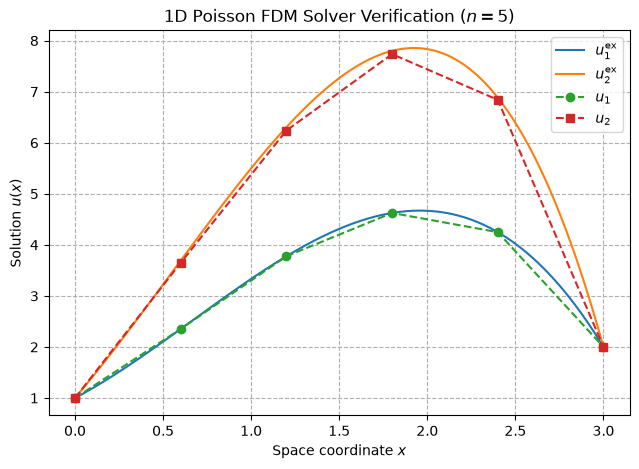

In [15]:
# Dense grid for smooth analytical solution curves
x_exact = np.linspace(0.0, 3.0, 500)

# Exact analytical solutions evaluated on the dense grid
u1_exact = (
    -0.5 * x_exact**3
    + x_exact**2
    + (11/6) * x_exact
    + 1
)

u2_exact = (
    -(1/12) * x_exact**4
    - 0.5 * x_exact**3
    + x_exact**2
    + (49/12) * x_exact
    + 1
)


# Overlay plot
plt.figure(figsize=(7.5, 5))

# Continuous exact solutions without discrete markers
plt.plot(x_exact, u1_exact, '-', label=r'$u_1^{\mathrm{ex}}$')
plt.plot(x_exact, u2_exact, '-', label=r'$u_2^{\mathrm{ex}}$')

# Discrete numerical solutions at the finite-difference grid points
plt.plot(x_mesh, u1_num, '--o', label=r'$u_1$')
plt.plot(x_mesh, u2_num, '--s', label=r'$u_2$')

plt.xlabel(r'Space coordinate $x$')
plt.ylabel(r'Solution $u(x)$')
plt.title(r'1D Poisson FDM Solver Verification ($n=5$)')
plt.grid(True, ls='--')
plt.legend()
plt.show()

### **Question 9: Continuous vs. Discrete Eigenvalue Analysis (2 p)**
Let the analytical eigenvalues of the continuous negative second-derivative operator $-d^2/dx^2$ be denoted as $\tilde{\lambda}_i$, and the analytical eigenvalues of the corresponding discrete FDM matrix $A$ as $\lambda_i$.

**Your Task:** Using your `assemble_system_matrix` function for $n=5$, numerically calculate the matrix eigenvalues using `np.linalg.eig()`. Sort them from smallest to largest and present them side-by-side with the analytical formulas inside the LaTeX table cell below.

--- 
*Double-click this cell to modify and fill out the values in this $\LaTeX$ Table:* 

| $i$ | Continuous Operator $\tilde{\lambda}_i$ | Discrete Analytical $\lambda_i$ | Numerical Array `np.linalg.eig()` |
|---|---:|---:|---:|
| 1 | $1.0966$ | $1.0610$ | $1.0610$ |
| 2 | $4.3865$ | $3.8388$ | $3.8388$ |
| 3 | $9.8696$ | $7.2723$ | $7.2723$ |
| 4 | $17.5460$ | $10.0501$ | $10.0501$ |

In [18]:
# TODO: Step 1. Assemble the test matrix A for n=5
A_eigen = assemble_system_matrix(n=5)

# TODO: Step 2. Compute and extract the numerical eigenvalues
raw_evals = np.sort(np.linalg.eig(A_eigen)[0])
# Hint: np.linalg.eig returns an unsorted tuple (values, vectors). Extract and sort the values!

print("Your computed and sorted numerical eigenvalues:\n", raw_evals)

Your computed and sorted numerical eigenvalues:
 [ 1.0610167   3.83879448  7.27231664 10.05009441]


For the continuous negative second-derivative operator, consider the eigenvalue problem

$$
-\frac{\mathrm d^2\phi_i}{\mathrm dx^2}
=
\tilde{\lambda}_i\phi_i,
\qquad x\in(0,L),
$$

with homogeneous Dirichlet boundary conditions $\phi_i(0)=\phi_i(L)=0.$ The analytical eigenvalues of the continuous operator are

$$
\tilde{\lambda}_i
=
\left(\frac{i\pi}{L}\right)^2,
\qquad i=1,2,\ldots
$$

For this problem, $L=3$, so
$$
\tilde{\lambda}_i
=
\left(\frac{i\pi}{3}\right)^2.
$$

The corresponding finite-difference matrix $A$ represents the same negative
second-derivative operator on the $n-1$ interior grid points. Its analytical
eigenvalues are

$$
\lambda_i
=
\frac{4}{h^2}
\sin^2\left(\frac{i\pi}{2n}\right),
\qquad i=1,\ldots,n-1,
$$

where $h=\frac{L}{n}.$ For $L=3$ and $n=5$,
$$
\lambda_i
=
\frac{4}{0.6^2}
\sin^2\left(\frac{i\pi}{10}\right),
\qquad i=1,\ldots,4.
$$

The discrete analytical eigenvalues agree with the eigenvalues computed
numerically using `np.linalg.eig()` to numerical precision. The difference
between the continuous and discrete eigenvalues is therefore caused by the
finite-difference discretization.
For small $i$, the corresponding eigenmodes vary slowly in space
and are well resolved by the grid. Consequently, the discrete eigenvalues
are close to the continuous eigenvalues. As $i$ increases, the eigenmodes
oscillate more and with higher frequency and are less accurately represented by the
coarse grid with $n=5$, leading to a larger difference between
$\lambda_i$ and $\tilde{\lambda}_i$.

As the grid is refined, $h\rightarrow0$ while $i$ is kept fixed, and the
discrete eigenvalues converge to the corresponding continuous eigenvalues:

$$
\lambda_i
\longrightarrow
\tilde{\lambda}_i
=
\left(\frac{i\pi}{L}\right)^2.
$$

The continuous version has infinitely many eigenvalues, whereas the
discrete matrix $A\in\mathbb{R}^{(n-1)\times(n-1)}$ has exactly $n-1$
eigenvalues. For $n=5$, this gives the four eigenvalues reported in the
table above.

### **Question 10(a): Global Error Log-Log Convergence Plot (1 p)**
We want to observe how the overall solution error behaves asymptotically as our discrete uniform mesh grid gets progressively finer.

**Your Task:** Run the convergence nested loop cell below. It will execute your solver dynamically across an array of increasing intervals ($n = [5, 10, 20, 40, 80, 160, 320, 640]$) and plot the Root-Mean-Squared-Errors (RMSE) using a log-log scaling perspective.


 n       RMSE f2          epsilon(n) / epsilon(2n)
5      5.50694107e-02   4.239457
10     1.29897315e-02   4.109417
20     3.16096724e-03   4.052278
40     7.80046999e-04   4.025559
80     1.93773603e-04   4.012638
160    4.82908232e-05   4.006284
320    1.20537684e-05   4.003134
640    3.01108273e-06          -


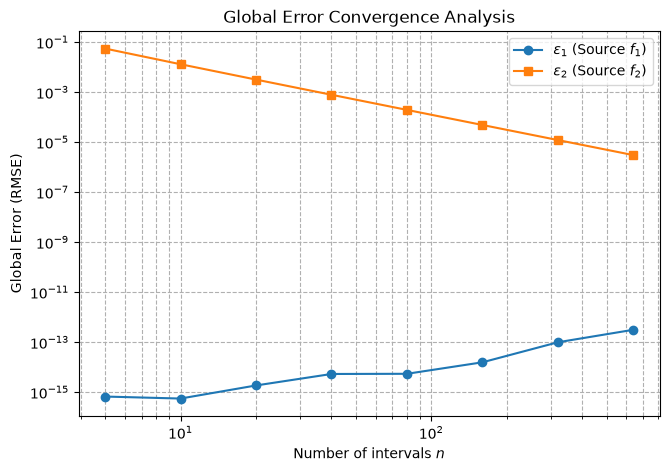

In [18]:
intervals = [5, 10, 20, 40, 80, 160, 320, 640]

errors_f1 = []
errors_f2 = []

for n in intervals:

    # Solve the Poisson problem
    x_mesh, u1_n, u2_n = solve_poisson_problem(n)

    # Exact analytical solutions evaluated at the grid nodes
    u1_exact = (
        -0.5 * x_mesh**3
        + x_mesh**2
        + (11/6) * x_mesh
        + 1
    )

    u2_exact = (
        -(1/12) * x_mesh**4
        - 0.5 * x_mesh**3
        + x_mesh**2
        + (49/12) * x_mesh
        + 1
    )

    # RMSE evaluated over the n-1 interior grid points
    rmse_1 = np.sqrt(
        np.mean((u1_n[1:-1] - u1_exact[1:-1])**2)
    )

    rmse_2 = np.sqrt(
        np.mean((u2_n[1:-1] - u2_exact[1:-1])**2)
    )

    errors_f1.append(rmse_1)
    errors_f2.append(rmse_2)


# Compute successive error ratios epsilon(n) / epsilon(2n)
ratios_f2 = [
    errors_f2[i] / errors_f2[i + 1]
    for i in range(len(errors_f2) - 1)
]


# Print convergence results
print(" n       RMSE f2          epsilon(n) / epsilon(2n)")

for i in range(len(intervals)):
    if i < len(ratios_f2):
        print(
            f"{intervals[i]:<6d} "
            f"{errors_f2[i]:<16.8e} "
            f"{ratios_f2[i]:.6f}"
        )
    else:
        print(
            f"{intervals[i]:<6d} "
            f"{errors_f2[i]:<16.8e} "
            f"{'-':>8}"
        )


# Log-log convergence plot
plt.figure(figsize=(7.5, 5))

plt.loglog(
    intervals,
    errors_f1,
    '-o',
    label=r'$\epsilon_1$ (Source $f_1$)'
)

plt.loglog(
    intervals,
    errors_f2,
    '-s',
    label=r'$\epsilon_2$ (Source $f_2$)'
)

plt.xlabel(r'Number of intervals $n$')
plt.ylabel('Global Error (RMSE)')
plt.title('Global Error Convergence Analysis')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()

### **Question 10(b): Analysis of Convergence Behavior (2 p)**

The different behaviour of $\epsilon_1$ and $\epsilon_2$ follows from the truncation error of the central finite-difference approximation.

For each interior node $x_i$,

$$
-u''(x_i)
=
\frac{-u_{i-1}+2u_i-u_{i+1}}{h^2}
+h^2p_i,
$$

where $p_i$ remains bounded as $h\rightarrow0$.

In the vector formulation below, $\mathbf{p}$ is defined with components
$[\mathbf{p}]_i=-p_i$, so that the exact discrete system can be written in
the form $A\mathbf{u}=\mathbf{f}+h^2\mathbf{p}$.

Hence, the local truncation error is

$$
\tau_i=h^2p_i=\mathcal{O}(h^2).
$$

For the complete discrete system, the exact grid-point solution $\mathbf{u}$ satisfies

$$
A\mathbf{u}=\mathbf{f}+h^2\mathbf{p},
$$

whereas the numerical solution $\widetilde{\mathbf{u}}$ satisfies

$$
A\widetilde{\mathbf{u}}=\mathbf{f}.
$$

Defining the global error as $\mathbf{e}=\mathbf{u}-\widetilde{\mathbf{u}}$ gives

$$
A\mathbf{e}=h^2\mathbf{p},
\qquad
\mathbf{e}=h^2A^{-1}\mathbf{p}.
$$

Since $A$ is symmetric positive definite,

$$
\|A^{-1}\|_2
=
\frac{1}{\lambda_{\min}(A)},
$$

with

$$
\lambda_{\min}(A)
=
\frac{4}{h^2}
\sin^2\left(\frac{\pi}{2n}\right)
\longrightarrow
\left(\frac{\pi}{L}\right)^2>0.
$$

Therefore, $\|A^{-1}\|_2$ remains bounded as $h\rightarrow0$.

Furthermore,

$$
\|\mathbf{e}\|_{2,h}
=
\frac{1}{\sqrt{n-1}}\|\mathbf{e}\|_2.
$$

Using $\mathbf{e}=h^2A^{-1}\mathbf{p}$ therefore gives

$$
\|\mathbf{e}\|_{2,h}
\leq
h^2
\|A^{-1}\|_2
\|\mathbf{p}\|_{2,h}.
$$

Since $\|A^{-1}\|_2$ remains bounded and
$\|\mathbf{p}\|_{2,h}$ remains bounded as $h\rightarrow0$,

$$
\|\mathbf{e}\|_{2,h}
=
\mathcal{O}(h^2).
$$

Since the RMSE used in this assignment is

$$
\epsilon
=
\|\mathbf{e}\|_{2,h}
=
\sqrt{
\frac{1}{n-1}
\sum_{i=1}^{n-1}e_i^2
},
$$

it follows that

$$
\epsilon=\mathcal{O}(h^2).
$$

For the first source function,

$$
u_1(x)
=
-\frac{1}{2}x^3+x^2+\frac{11}{6}x+1,
$$

so

$$
u_1^{(4)}(x)=0.
$$

Hence, the central second-difference formula is exact for $u_1$ at the grid points. Therefore, theoretically $\epsilon_1=0$, and the small non-zero values in the numerical results are due to floating-point round-off.

For the second source function,

$$
u_2(x)
=
-\frac{1}{12}x^4-\frac{1}{2}x^3+x^2+\frac{49}{12}x+1,
$$

for which

$$
u_2^{(4)}(x)=-2\neq0.
$$

Thus, the truncation error does not vanish and

$$
\epsilon_2=\mathcal{O}(h^2).
$$

To verify the convergence rate numerically, assume

$$
\epsilon_2\approx Ch^p.
$$

Since doubling the number of intervals halves the grid spacing,

$$
h_{2n}=\frac{h_n}{2},
$$

and therefore

$$
\frac{\epsilon_2(n)}{\epsilon_2(2n)}
\approx
2^p.
$$

Hence, the observed order is

$$
p=
\frac{
\log\left(\epsilon_2(n)/\epsilon_2(2n)\right)
}{
\log 2
}.
$$

For quadratic convergence, the error ratio approaches $4$ and therefore $p\rightarrow2$. The computed ratios approach this value as the grid is refined, confirming that the finite-difference scheme is second-order accurate.

Specifically, the successive values of

$$
\frac{\epsilon_2(n)}{\epsilon_2(2n)}
$$

are approximately

$$
4.239,\quad
4.109,\quad
4.052,\quad
4.026,\quad
4.013,\quad
4.006,\quad
4.003,
$$

which clearly converge to $4$. The corresponding observed convergence orders are approximately

$$
2.084,\quad
2.039,\quad
2.019,\quad
2.009,\quad
2.005,\quad
2.002,\quad
2.001,
$$

which converge to $p=2$.

Finally, because $h=L/n$,

$$
\epsilon_2\propto n^{-2},
$$

so the log-log plot of RMSE against $n$ approaches a straight line with slope $-2$.